In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)  # Menampilkan semua kolom
pd.set_option('display.max_colwidth', None)  # Menampilkan isi seluruh kolom tanpa pemotongan

In [4]:
data = pd.read_csv("wifi.csv")
data.head()

,waktu,Fakultas,prodi,device,Gedung,lokasiakses,waktubermasalah,deskripsipengalaman,keluhanutama,yangdisukai,pesan,Tingkatkepuasan
0,2025/12/30 9:16:21 PM GMT+7,Ilmu Komputer,Sistem Informasi,Laptop,Gedung F,Ruang Kelas,Pagi (08.00 - 11.00),Emosi,"Lemot banget, gila",Gak ada,Tolong dong wifi nya lancar di semua gedungggg,Tidak Puas
1,2025/12/31 12:42:01 PM GMT+7,Teknologi Informasi,Sistem Informasi,Smartphone,Gedung A,Ruang Kelas;Kantin;Lab Komputer,Siang (11.00 - 14.00),Kurang,Kadang lemot,Gratis,Tolong buat lebih cepat,Tidak Puas
2,2026/01/01 5:06:08 PM GMT+7,Ilmu Komputer,Sistem Informasi brodie,Laptop,Gedung F,Perpustakaan;Ruang Kelas,Siang (11.00 - 14.00),Lambatnya mantap,"LELET JIR, GA LENGKAP DI SEMUA BANGUNAN",Lelet bund,Tambah bandwidth nya bwang flish,Sangat mengecewakan
3,2026/01/02 11:43:47 AM GMT+7,Ilmu komputer,Sistem Informasi,Smartphone,Gedung B,Perpustakaan;Lab Komputer,Siang (11.00 - 14.00),Nice,kadang lelet,gratis,jaringan belum mencapai semua daerah kampus untuk di akses,Netral
4,2026/01/02 11:58:49 AM GMT+7,Ilmu Komputer,Sistem Informasi,Laptop,Gedung F,Perpustakaan;Ruang Kelas;Lab Komputer,Siang (11.00 - 14.00),Lambat,Speed sangat tidak mencukupi untuk donwload software yang diminta dosen.,Tidak ada,Tingkatkan speed dan jangkauan,Sangat mengecewakan


In [6]:
# menghapus kolom yang tidak akan digunakan
data = data.drop(columns=['waktu', 'Fakultas', 'prodi', 'device', 'Gedung', 'lokasiakses', 'waktubermasalah','deskripsipengalaman', 'yangdisukai', 'pesan', 'Tingkatkepuasan'])
data

,keluhanutama
0,"Lemot banget, gila"
1,Kadang lemot
2,"LELET JIR, GA LENGKAP DI SEMUA BANGUNAN"
3,kadang lelet
4,Speed sangat tidak mencukupi untuk donwload software yang diminta dosen.
...,...
96,lemot
97,susah sinyal
98,jelek sinyalnya
99,jaringannya lambat


In [8]:
data['keluhanutama'].fillna('test', inplace=True)
data.head()

C:\Users\user\AppData\Local\Temp\ipykernel_21268\301183919.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['keluhanutama'].fillna('test', inplace=True)


,keluhanutama
0,"Lemot banget, gila"
1,Kadang lemot
2,"LELET JIR, GA LENGKAP DI SEMUA BANGUNAN"
3,kadang lelet
4,Speed sangat tidak mencukupi untuk donwload software yang diminta dosen.


In [10]:
import re # Mengimpor modul re
# membuat fungsi untuk data cleaning
def datacleaning(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus retweet
    text = re.sub(r'[?|$|.|@#%^/&*=!_:")(-+,]', '', text) # menghapus simbol
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = text.replace('\n', ' ') # mengganti baris baru menjadi spasi
    text = text.strip(' ') # hapus spasi dari kiri dan kanan teks
    return text

data['keluhanutama'] = data['keluhanutama'].apply(datacleaning)
data

,keluhanutama
0,Lemot banget gila
1,Kadang lemot
2,LELET JIR GA LENGKAP DI SEMUA BANGUNAN
3,kadang lelet
4,Speed sangat tidak mencukupi untuk donwload software yang diminta dosen
...,...
96,lemot
97,susah sinyal
98,jelek sinyalnya
99,jaringannya lambat


In [12]:
# case folding

In [12]:
def CaseFolding(text): # mengubah semua kata menjadi bentuk lower case
    text = text.lower() 
    return text

data['keluhanutama'] = data['keluhanutama'].apply(CaseFolding)
data

,keluhanutama
0,lemot banget gila
1,kadang lemot
2,lelet jir ga lengkap di semua bangunan
3,kadang lelet
4,speed sangat tidak mencukupi untuk donwload software yang diminta dosen
...,...
96,lemot
97,susah sinyal
98,jelek sinyalnya
99,jaringannya lambat


In [ ]:
# tokenizing

In [14]:
import nltk
from nltk.tokenize import word_tokenize

def Tokenizing(text):
    text = word_tokenize(text) 
    return text

data['keluhanutama'] = data['keluhanutama'].apply(Tokenizing)
data

,keluhanutama
0,"[lemot, banget, gila]"
1,"[kadang, lemot]"
2,"[lelet, jir, ga, lengkap, di, semua, bangunan]"
3,"[kadang, lelet]"
4,"[speed, sangat, tidak, mencukupi, untuk, donwload, software, yang, diminta, dosen]"
...,...
96,[lemot]
97,"[susah, sinyal]"
98,"[jelek, sinyalnya]"
99,"[jaringannya, lambat]"


In [ ]:
# stopword

In [16]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
import nltk 
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
>>> import nltk
>>> nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [24]:
import nltk
from nltk.corpus import stopwords
                    
stop_words = set(stopwords.words('indonesian'))

def Filtering(text):
    clean_words = []
    for word in text:
        if word not in stop_words:
            clean_words.append(word)
    return " ".join(clean_words)

data['keluhanutama'] = data['keluhanutama'].apply(Filtering)
data

,keluhanutama
0,lemot banget gila
1,kadang lemot
2,lelet jir ga lengkap bangunan
3,kadang lelet
4,speed mencukupi donwload software dosen
...,...
96,lemot
97,susah sinyal
98,jelek sinyalnya
99,jaringannya lambat


In [ ]:
#Stemming

In [26]:
pip install Sastrawi

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install --upgrade pip setuptools

In [28]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Buat fungsi untuk langkah stemming bahasa Indonesia
def Stemming(text):
    text = stemmer.stem(text)
    return text

data['keluhanutama'] = data['keluhanutama'].apply(Stemming)
data

data.to_csv('wifi2.csv', index=False)

In [60]:
import pandas as pd

data = pd.read_csv("wifi2.csv")
data

,keluhanutama
0,lot banget gila
1,kadang lot
2,lelet jir ga lengkap bangun
3,kadang lelet
4,speed cukup donwload software dosen
...,...
96,lot
97,susah sinyal
98,jelek sinyal
99,jaring lambat


In [62]:
data['keluhanutama'].fillna('test', inplace=True)
data.head()

C:\Users\user\AppData\Local\Temp\ipykernel_21268\301183919.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['keluhanutama'].fillna('test', inplace=True)


,keluhanutama
0,lot banget gila
1,kadang lot
2,lelet jir ga lengkap bangun
3,kadang lelet
4,speed cukup donwload software dosen


In [64]:
import csv

lexicon_positive = dict()
with open('lexicon_positive_ver1.csv', 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])

lexicon_negative = dict()
with open('lexicon_negative_ver1.csv', 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])

def sentiment_analysis_lexicon_indonesia(text):
  score = 0
  for word_pos in text:
    if (word_pos in lexicon_positive):
      score = score + lexicon_positive[word_pos]
  for word_neg in text:
    if (word_neg in lexicon_negative):
      score = score + lexicon_negative[word_neg]
  Sentimen=''
  if (score > 0):
    Sentimen = 'positif'
  elif (score < 0):
    Sentimen = 'negatif'
  else:
    Sentimen = 'netral'
  
  return score, Sentimen

In [66]:
data['keluhanutama'] = data.keluhanutama.str.split()
data

,keluhanutama
0,"[lot, banget, gila]"
1,"[kadang, lot]"
2,"[lelet, jir, ga, lengkap, bangun]"
3,"[kadang, lelet]"
4,"[speed, cukup, donwload, software, dosen]"
...,...
96,[lot]
97,"[susah, sinyal]"
98,"[jelek, sinyal]"
99,"[jaring, lambat]"


In [68]:
results = data['keluhanutama'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
data['score'] = results[0]
data['Sentimen'] = results[1]
print(data['Sentimen'].value_counts())

Sentimen
negatif    38
netral     34
positif    29
Name: count, dtype: int64


In [70]:
def convert_tokens_to_text(tokens):
    text = ' '.join(tokens)
    return text

In [72]:
data['keluhanutama'] = data['keluhanutama'].apply(convert_tokens_to_text)

print(data)

                            keluhanutama  score Sentimen
0                        lot banget gila     -6  negatif
1                             kadang lot     -2  negatif
2            lelet jir ga lengkap bangun     -4  negatif
3                           kadang lelet      3  positif
4    speed cukup donwload software dosen     -5  negatif
..                                   ...    ...      ...
96                                   lot     -5  negatif
97                          susah sinyal     -3  negatif
98                          jelek sinyal     -5  negatif
99                         jaring lambat      4  positif
100                           lot banget     -4  negatif

[101 rows x 3 columns]


In [74]:
# menghapus kolom yang tidak akan digunakan
data = data.drop(columns=['score'])
data

,keluhanutama,Sentimen
0,lot banget gila,negatif
1,kadang lot,negatif
2,lelet jir ga lengkap bangun,negatif
3,kadang lelet,positif
4,speed cukup donwload software dosen,negatif
...,...,...
96,lot,negatif
97,susah sinyal,negatif
98,jelek sinyal,negatif
99,jaring lambat,positif


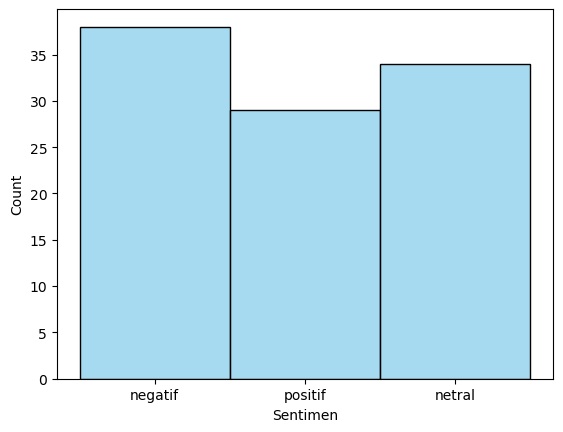

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots()

sns.histplot(data=data, x='Sentimen', color='skyblue')

plt.show()

In [78]:
data.to_csv('wifi3.csv', index=False)

In [80]:
import pandas as pd

pd.set_option('display.max_columns', None)  # Menampilkan semua kolom
pd.set_option('display.max_colwidth', None)  # Menampilkan isi seluruh kolom tanpa pemotongan

In [82]:
data = pd.read_csv("wifi3.csv")
data.head()

,keluhanutama,Sentimen
0,lot banget gila,negatif
1,kadang lot,negatif
2,lelet jir ga lengkap bangun,negatif
3,kadang lelet,positif
4,speed cukup donwload software dosen,negatif


In [88]:
# Pisahkan kolom fitur dan target
X = data['keluhanutama']
y = data['Sentimen']

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer()
tf_idf.fit(X)

X_tf_idf = tf_idf.transform(X).toarray()

data_tf_idf = pd.DataFrame(X_tf_idf, columns=tf_idf.get_feature_names_out())
data_tf_idf

,aja,akses,aman,asli,bagus,baik,banget,bangun,beberapa,beberpa,betul,bilang,buruk,buset,cafe,cepat,connect,coy,cukup,digunain,dipake,donwload,dosen,eror,ga,gaada,gabisa,ganggu,gasuka,gedung,gila,gitu,guna,help,hilang,ih,internet,internetan,jangkau,jaring,jatingannya,jelek,jir,kadang,kafang,kalo,kantin,kaya,kelas,kemot,kencang,kenceng,koneksi,kuat,kuota,lab,lag,lah,lambat,leeletttttttttt,leket,lelet,lengkap,lot,luar,mampus,masalah,me,ngerti,nikmat,nugas,nya,oake,ok,padang,pake,parah,parahhhh,putus,ruang,sabar,samsek,sana,segacor,sih,sinyal,siput,software,speed,speednya,stabil,suka,sulit,susah,terkadang,test,timbul,udah,wak,wifi,wifinya,ya,yg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.466376,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.751656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.466376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.745988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.665959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.519902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.307495,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.307495,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.761573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.648079,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.454436,0.0,0.0,0.454436,0.454436,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.454436,0.417075,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tf_idf, y, test_size = 0.3, random_state = 37)

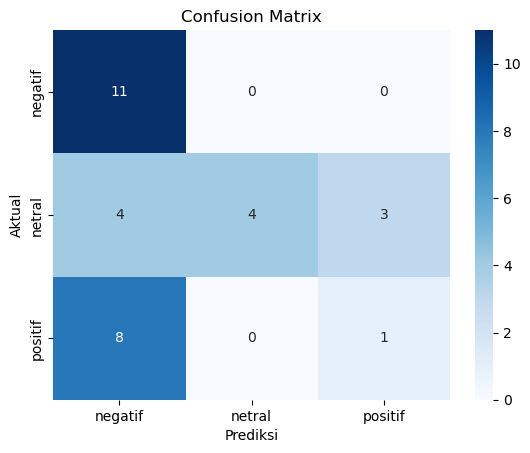

Accuracy Score untuk C4.5 Model ::  0.5161290322580645
              precision    recall  f1-score   support

     negatif       0.48      1.00      0.65        11
      netral       1.00      0.36      0.53        11
     positif       0.25      0.11      0.15         9

    accuracy                           0.52        31
   macro avg       0.58      0.49      0.44        31
weighted avg       0.60      0.52      0.46        31



In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dc_classifier = DecisionTreeClassifier(max_depth=3, criterion="entropy")
dc_classifier.fit(X_train, y_train)
y_pred = dc_classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
label_names = np.unique(y)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

print("Accuracy Score untuk C4.5 Model :: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

In [ ]:
#Pemodelan SVM

In [8]:
import pandas as pd

pd.set_option('display.max_columns', None)  # Menampilkan semua kolom
pd.set_option('display.max_colwidth', None)  # Menampilkan isi seluruh kolom tanpa pemotongan


In [10]:
data = pd.read_csv("wifi3.csv")
data.head()


,keluhanutama,Sentimen
0,lot banget gila,negatif
1,kadang lot,negatif
2,lelet jir ga lengkap bangun,negatif
3,kadang lelet,positif
4,speed cukup donwload software dosen,negatif


In [12]:
# Pisahkan kolom fitur dan target
X = data['keluhanutama']
y = data['Sentimen']


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer()
tf_idf.fit(X)

X_tf_idf = tf_idf.transform(X).toarray()

data_tf_idf = pd.DataFrame(X_tf_idf, columns=tf_idf.get_feature_names_out())
data_tf_idf


,aja,akses,aman,asli,bagus,baik,banget,bangun,beberapa,beberpa,betul,bilang,buruk,buset,cafe,cepat,connect,coy,cukup,digunain,dipake,donwload,dosen,eror,ga,gaada,gabisa,ganggu,gasuka,gedung,gila,gitu,guna,help,hilang,ih,internet,internetan,jangkau,jaring,jatingannya,jelek,jir,kadang,kafang,kalo,kantin,kaya,kelas,kemot,kencang,kenceng,koneksi,kuat,kuota,lab,lag,lah,lambat,leeletttttttttt,leket,lelet,lengkap,lot,luar,mampus,masalah,me,ngerti,nikmat,nugas,nya,oake,ok,padang,pake,parah,parahhhh,putus,ruang,sabar,samsek,sana,segacor,sih,sinyal,siput,software,speed,speednya,stabil,suka,sulit,susah,terkadang,test,timbul,udah,wak,wifi,wifinya,ya,yg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.466376,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.751656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.466376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.745988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.665959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.519902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.307495,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.307495,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.761573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.648079,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.454436,0.0,0.0,0.454436,0.454436,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.454436,0.417075,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tf_idf, y, test_size = 0.3, random_state = 37)


In [18]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

svm=svm.SVC(class_weight=None,C=1,gamma=0.1,kernel='linear',random_state=100, probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

cm = confusion_matrix(y_test, svm_pred)
label_names = np.unique(y) 


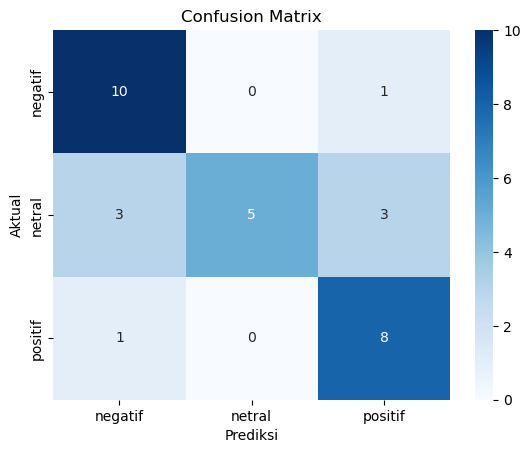

Accuracy Score untuk Support Vector Machine Model ::  0.7419354838709677
              precision    recall  f1-score   support

     negatif       0.71      0.91      0.80        11
      netral       1.00      0.45      0.62        11
     positif       0.67      0.89      0.76         9

    accuracy                           0.74        31
   macro avg       0.79      0.75      0.73        31
weighted avg       0.80      0.74      0.73        31



In [20]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

print("Accuracy Score untuk Support Vector Machine Model :: ", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))


In [ ]:
#Pemodelan KNN

In [22]:
import pandas as pd

pd.set_option('display.max_columns', None)  # Menampilkan semua kolom
pd.set_option('display.max_colwidth', None)  # Menampilkan isi seluruh kolom tanpa pemotongan


In [24]:
data = pd.read_csv("wifi3.csv")
data.head()


,keluhanutama,Sentimen
0,lot banget gila,negatif
1,kadang lot,negatif
2,lelet jir ga lengkap bangun,negatif
3,kadang lelet,positif
4,speed cukup donwload software dosen,negatif


In [26]:
# Pisahkan kolom fitur dan target
X = data['keluhanutama']
y = data['Sentimen']


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer()
tf_idf.fit(X)

X_tf_idf = tf_idf.transform(X).toarray()

data_tf_idf = pd.DataFrame(X_tf_idf, columns=tf_idf.get_feature_names_out())
data_tf_idf


,aja,akses,aman,asli,bagus,baik,banget,bangun,beberapa,beberpa,betul,bilang,buruk,buset,cafe,cepat,connect,coy,cukup,digunain,dipake,donwload,dosen,eror,ga,gaada,gabisa,ganggu,gasuka,gedung,gila,gitu,guna,help,hilang,ih,internet,internetan,jangkau,jaring,jatingannya,jelek,jir,kadang,kafang,kalo,kantin,kaya,kelas,kemot,kencang,kenceng,koneksi,kuat,kuota,lab,lag,lah,lambat,leeletttttttttt,leket,lelet,lengkap,lot,luar,mampus,masalah,me,ngerti,nikmat,nugas,nya,oake,ok,padang,pake,parah,parahhhh,putus,ruang,sabar,samsek,sana,segacor,sih,sinyal,siput,software,speed,speednya,stabil,suka,sulit,susah,terkadang,test,timbul,udah,wak,wifi,wifinya,ya,yg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.466376,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.751656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.466376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.745988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.665959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.519902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.307495,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.307495,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.761573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.648079,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.454436,0.0,0.0,0.454436,0.454436,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.454436,0.417075,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tf_idf, y, test_size = 0.3, random_state = 37)


In [32]:
from sklearn.neighbors import KNeighborsClassifier 
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


In [34]:
from sklearn.metrics import classification_report, confusion_matrix

In [36]:
import numpy as np
import seaborn as sns


In [38]:
errors = []
for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    errors.append(1 - knn.score(X_test, y_test))


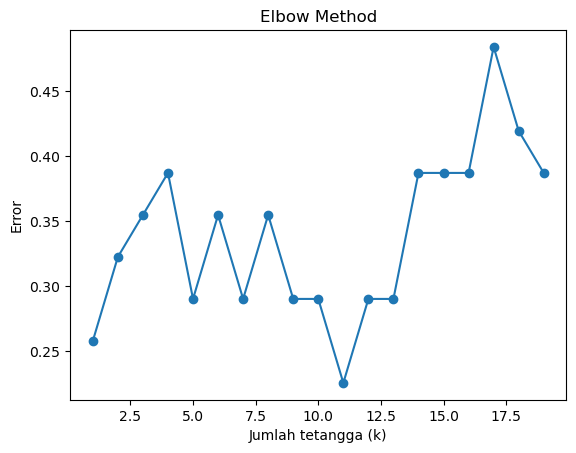

In [40]:
# Plot elbow method
plt.plot(range(1, 20), errors, marker='o')
plt.xlabel('Jumlah tetangga (k)')
plt.ylabel('Error')
plt.title('Elbow Method')
plt.show()


In [42]:
# Menentukan nilai k terbaik berdasarkan elbow method
best_k = errors.index(min(errors)) + 1
print("Nilai k terbaik: ", best_k)



Nilai k terbaik:  11


In [44]:
# Melatih model KNN dengan nilai k terbaik
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=11)

In [46]:
# Prediksi sentimen pada data uji
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
label_names = np.unique(y)


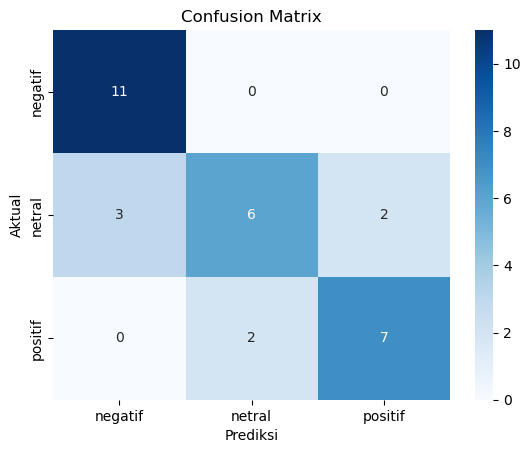

In [48]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


In [50]:
print(classification_report(y_test, y_pred, zero_division=0))
print("\nKNN :" , accuracy_score(y_test, y_pred))
print('-------------------------------------------')


              precision    recall  f1-score   support

     negatif       0.79      1.00      0.88        11
      netral       0.75      0.55      0.63        11
     positif       0.78      0.78      0.78         9

    accuracy                           0.77        31
   macro avg       0.77      0.77      0.76        31
weighted avg       0.77      0.77      0.76        31


KNN : 0.7741935483870968
-------------------------------------------


In [ ]:
#Pemodelan Random Forest

In [52]:
import pandas as pd

pd.set_option('display.max_columns', None)  # Menampilkan semua kolom
pd.set_option('display.max_colwidth', None)  # Menampilkan isi seluruh kolom tanpa pemotongan


In [54]:
data = pd.read_csv("wifi3.csv")
data.head()

,keluhanutama,Sentimen
0,lot banget gila,negatif
1,kadang lot,negatif
2,lelet jir ga lengkap bangun,negatif
3,kadang lelet,positif
4,speed cukup donwload software dosen,negatif


In [56]:
# Pisahkan kolom fitur dan target
X = data['keluhanutama']
y = data['Sentimen']


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer()
tf_idf.fit(X)

X_tf_idf = tf_idf.transform(X).toarray()

data_tf_idf = pd.DataFrame(X_tf_idf, columns=tf_idf.get_feature_names_out())
data_tf_idf


,aja,akses,aman,asli,bagus,baik,banget,bangun,beberapa,beberpa,betul,bilang,buruk,buset,cafe,cepat,connect,coy,cukup,digunain,dipake,donwload,dosen,eror,ga,gaada,gabisa,ganggu,gasuka,gedung,gila,gitu,guna,help,hilang,ih,internet,internetan,jangkau,jaring,jatingannya,jelek,jir,kadang,kafang,kalo,kantin,kaya,kelas,kemot,kencang,kenceng,koneksi,kuat,kuota,lab,lag,lah,lambat,leeletttttttttt,leket,lelet,lengkap,lot,luar,mampus,masalah,me,ngerti,nikmat,nugas,nya,oake,ok,padang,pake,parah,parahhhh,putus,ruang,sabar,samsek,sana,segacor,sih,sinyal,siput,software,speed,speednya,stabil,suka,sulit,susah,terkadang,test,timbul,udah,wak,wifi,wifinya,ya,yg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.466376,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.751656,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.466376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.745988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.665959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.519902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.307495,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.307495,0.519902,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.761573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.648079,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.454436,0.0,0.0,0.454436,0.454436,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.454436,0.417075,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tf_idf, y, test_size = 0.3, random_state = 37)


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
label_names = np.unique(y)


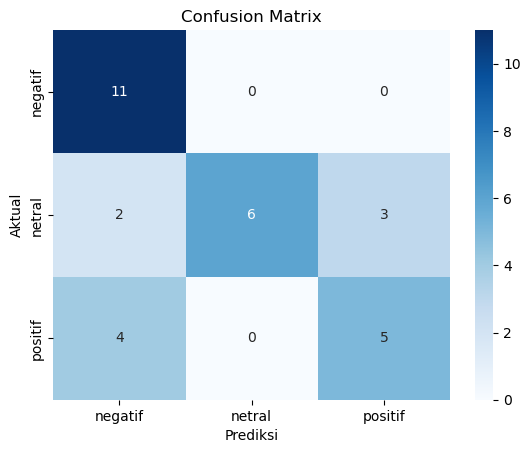

In [66]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


In [68]:
print("Accuracy Score untuk RandomForestClassifier Model :: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy Score untuk RandomForestClassifier Model ::  0.7096774193548387
              precision    recall  f1-score   support

     negatif       0.65      1.00      0.79        11
      netral       1.00      0.55      0.71        11
     positif       0.62      0.56      0.59         9

    accuracy                           0.71        31
   macro avg       0.76      0.70      0.69        31
weighted avg       0.77      0.71      0.70        31



In [ ]:
#NAIVE BAYES

In [70]:
# === 1. Import library ===
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [72]:
# === 2. Load Dataset ===
# Pastikan file gabungan.csv sudah diupload ke Colab
df = pd.read_csv("wifi3.csv")

# Cek isi dataset
print(df.head())



                          keluhanutama Sentimen
0                      lot banget gila  negatif
1                           kadang lot  negatif
2          lelet jir ga lengkap bangun  negatif
3                         kadang lelet  positif
4  speed cukup donwload software dosen  negatif


In [74]:
# === 3. Pisahkan fitur (Ulasan) dan label (Sentimen) ===
X = df['keluhanutama']       # teks ulasan
y = df['Sentimen']        # label sentimen (positif/negatif/netral)



In [76]:
# === 4. Split data train & test ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [78]:
# === 5. TF-IDF Vectorization ===
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)



In [80]:
# === 6. Naive Bayes Classifier ===
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)



MultinomialNB()

In [82]:
# === 7. Prediksi ===
y_pred = nb.predict(X_test_tfidf)



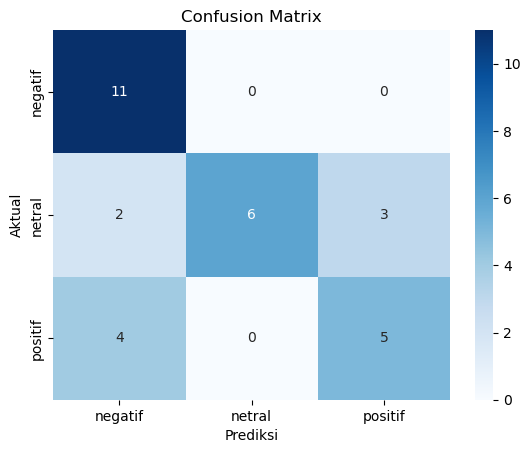

In [84]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


In [86]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy Score untuk NaiveBayes Model :: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy Score untuk NaiveBayes Model ::  0.6190476190476191
              precision    recall  f1-score   support

     negatif       0.75      0.67      0.71         9
      netral       0.38      1.00      0.55         3
     positif       0.80      0.44      0.57         9

    accuracy                           0.62        21
   macro avg       0.64      0.70      0.61        21
weighted avg       0.72      0.62      0.63        21



In [88]:
import joblib

# === Simpan model dan vectorizer ===
joblib.dump(nb, "nb_model.pkl")
joblib.dump(vectorizer, "tfidf.pkl")

print("Model & Vectorizer berhasil disimpan ✅")


Model & Vectorizer berhasil disimpan ✅


In [92]:
# === Load model & vectorizer ===
nb = joblib.load("nb_model.pkl")
vectorizer = joblib.load("tfidf.pkl")

# === Contoh prediksi baru ===
X_input = vectorizer.transform(contoh)
pred = nb.predict(X_input)
print("Prediksi:", pred[0])


Prediksi: netral


In [3]:
import pandas as pd

hasil_model = {
    'Model': [
        'Naive Bayes',
        'SVM',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        0.62,
        0.74,
        0.77,
        0.52,
        0.71
    ]
}

df_hasil = pd.DataFrame(hasil_model)

print(df_hasil)

           Model  Accuracy
0    Naive Bayes      0.62
1            SVM      0.74
2            KNN      0.77
3  Decision Tree      0.52
4  Random Forest      0.71


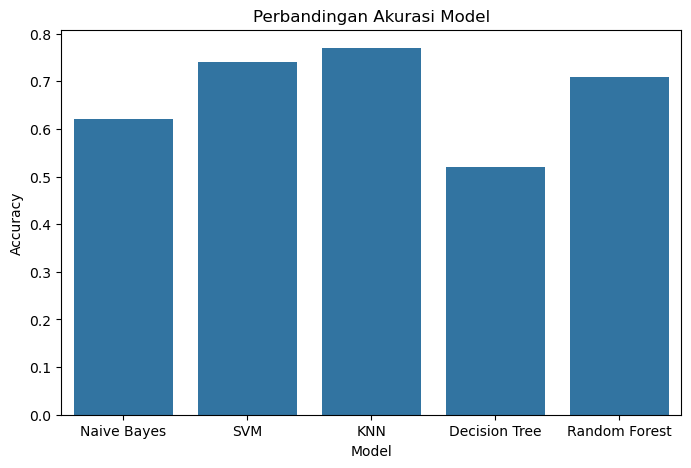

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_hasil,
    x='Model',
    y='Accuracy'
)

plt.title('Perbandingan Akurasi Model')
plt.ylabel('Accuracy')
plt.xlabel('Model')

plt.savefig('model_comparison.png', bbox_inches='tight')

plt.show()